In [57]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [58]:
# ==========================================
# STEP 1: DOWNLOAD & LOAD THE DATASET
# ==========================================
print("📥 Downloading dataset from Kaggle...")
# Download latest version of the Crop Recommendation Dataset
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")
print("Path to dataset files:", path)

# Find the CSV file inside the downloaded directory
csv_filename = "Crop_recommendation.csv"
csv_path = os.path.join(path, csv_filename)

# Load into Pandas DataFrame
df = pd.read_csv(csv_path)
print(f"✅ Dataset loaded successfully! Shape: {df.shape}")

# Quick EDA (Exploratory Data Analysis)
print("\n--- First 5 Rows of the Dataset ---")
print(df.head())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

📥 Downloading dataset from Kaggle...
Path to dataset files: /kaggle/input/datasets/atharvaingle/crop-recommendation-dataset
✅ Dataset loaded successfully! Shape: (2200, 8)

--- First 5 Rows of the Dataset ---
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

--- Missing Values Check ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [59]:
# ==========================================
# STEP 2: PREPROCESSING & ENCODING
# ==========================================
print("\n⚙️ Preprocessing data...")

# XGBoost requires target variables to be integer-encoded (0 to N-1)
label_encoder = LabelEncoder()
df['crop_encoded'] = label_encoder.fit_transform(df['label'])

# Features (X) and Target (y)
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['crop_encoded']

# Split the dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


⚙️ Preprocessing data...
Training set size: 1760 samples
Testing set size: 440 samples


In [60]:
# ==========================================
# STEP 3: TRAIN & COMPARE MODELS
# ==========================================
print("\n🏋️ Training models...")

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42, probability=True),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# Dictionary to hold accuracy scores
model_accuracies = {}
trained_models = {}

for name, model in models.items():
    # Fit model on scaled data (SVM is sensitive to unscaled data, others handle it well)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, predictions)
    model_accuracies[name] = accuracy
    trained_models[name] = model
    print(f"👉 {name} Accuracy: {accuracy * 100:.2f}%")

# Select the best performing model automatically
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Model Selected: {best_model_name} ({model_accuracies[best_model_name]*100:.2f}%)")

# Detailed evaluation of the best model
y_pred_best = best_model.predict(X_test_scaled)
print(f"\n--- Classification Report for {best_model_name} ---")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))


🏋️ Training models...
👉 Decision Tree Accuracy: 97.95%
👉 Random Forest Accuracy: 99.55%
👉 Support Vector Machine Accuracy: 98.41%
👉 XGBoost Accuracy: 99.32%

🏆 Best Model Selected: Random Forest (99.55%)

--- Classification Report for Random Forest ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00

In [61]:
# ==========================================
# STEP 4: DATA-DRIVEN FERTILIZER ADVISOR
# ==========================================
# Calculate the ideal average (mean) N, P, K requirements for every crop
print("\n🧮 Calculating baseline nutrient requirements for fertilizer advisor...")
crop_baselines = df.groupby('label')[['N', 'P', 'K']].mean().to_dict('index')

def fertilizer_advisor(predicted_crop, current_n, current_p, current_k):
    """
    Compares the user's current soil nutrients against the baseline 
    averages for the predicted crop, and suggests fertilizer corrections.
    """
    baseline = crop_baselines[predicted_crop]
    ideal_n = baseline['N']
    ideal_p = baseline['P']
    ideal_k = baseline['K']
    
    # Calculate deficiencies (threshold of 10 units)
    advice = []
    
    if current_n < (ideal_n - 10):
        diff = round(ideal_n - current_n, 1)
        advice.append(f"• Nitrogen (N) is low by {diff} units. Suggest adding Urea or Ammonium Nitrate.")
    elif current_n > (ideal_n + 15):
        advice.append("• Nitrogen (N) is high. Avoid nitrogen-heavy fertilizers to prevent vegetative overgrowth.")
        
    if current_p < (ideal_p - 10):
        diff = round(ideal_p - current_p, 1)
        advice.append(f"• Phosphorus (P) is low by {diff} units. Suggest applying DAP (Di-Ammonium Phosphate) or Single Superphosphate.")
        
    if current_k < (ideal_k - 10):
        diff = round(ideal_k - current_k, 1)
        advice.append(f"• Potassium (K) is low by {diff} units. Suggest adding Muriate of Potash (MOP).")
        
    if not advice:
        advice.append("• Your N-P-K nutrient levels are well-balanced for this crop! No immediate fertilizer corrective actions needed.")
        
    return advice


🧮 Calculating baseline nutrient requirements for fertilizer advisor...


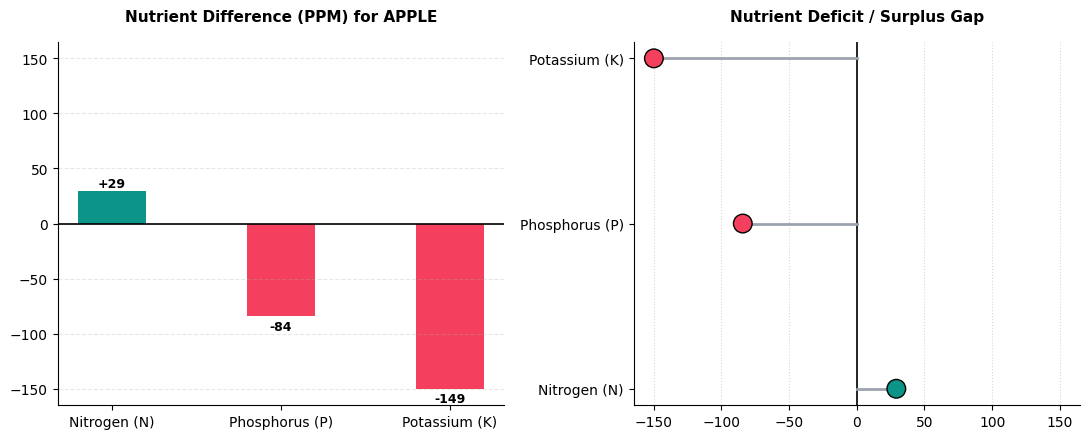

/tmp/ipykernel_58/2956408712.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, patch_artist=True, labels=cats, widths=0.4,


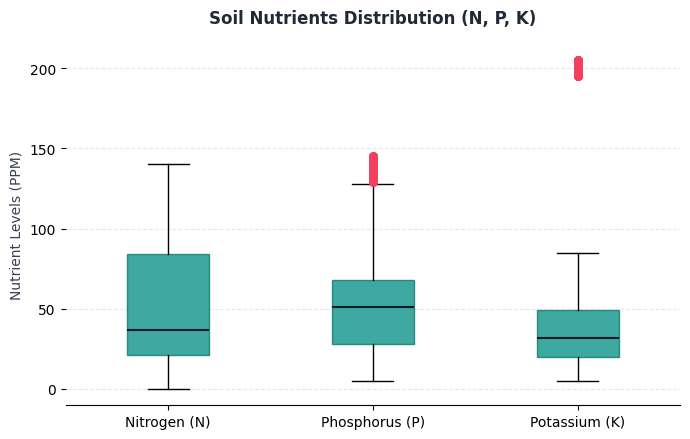

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the exact difference (Your Soil - Ideal Soil)
baseline = crop_baselines[pred_crop]
categories = ['Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)']
differences = [user_n - baseline['N'], user_p - baseline['P'], user_k - baseline['K']]

# Create side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Define color theme: Teal for Surplus (>= 0), Rose/Red for Deficit (< 0)
colors = ['#0D9488' if diff >= 0 else '#F43F5E' for diff in differences]

# --- Graph 1: Difference Bar Chart ---
bars = ax1.bar(categories, differences, color=colors, width=0.4)
ax1.axhline(0, color='black', linewidth=1.2, linestyle='-')  # Baseline at zero
ax1.set_title(f"Nutrient Difference (PPM) for {pred_crop.upper()}", fontsize=11, fontweight='bold', pad=15)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Annotate bars with values
for bar in bars:
    height = bar.get_height()
    va_direction = 'bottom' if height >= 0 else 'top'
    offset = 1 if height >= 0 else -3
    ax1.text(bar.get_x() + bar.get_width()/2, height + offset, 
             f"{'+' if height > 0 else ''}{int(height)}", 
             ha='center', va=va_direction, fontweight='bold', fontsize=9)

# --- Graph 2: Difference Scatter/Lollipop Plot ---
y_positions = np.arange(3)
ax2.axvline(0, color='black', linewidth=1.2, linestyle='-')  # Baseline at zero
for i in range(3):
    ax2.plot([0, differences[i]], [i, i], color='#9CA3AF', linestyle='-', linewidth=2)
ax2.scatter(differences, y_positions, color=colors, s=180, edgecolors='black', zorder=3)
ax2.set_yticks(y_positions)
ax2.set_yticklabels(categories)
ax2.set_title("Nutrient Deficit / Surplus Gap", fontsize=11, fontweight='bold', pad=15)
ax2.grid(axis='x', linestyle=':', alpha=0.5)

# Adjust limits symmetrically for optimal display
max_val = max(abs(diff) for diff in differences) + 15
ax1.set_ylim(-max_val, max_val)
ax2.set_xlim(-max_val, max_val)

# Clean up spines (borders) for a modern flat UI look
for ax in [ax1, ax2]:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

# 1. Dataset se N, P, K ka data nikalein
data = [df['N'], df['P'], df['K']]
cats = ['Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)']

plt.figure(figsize=(7, 4.5))

# 2. Boxplot draw karein (Modern Teal Theme)
box = plt.boxplot(data, patch_artist=True, labels=cats, widths=0.4,
                  medianprops=dict(color='#111827', linewidth=1.5),
                  flierprops=dict(marker='o', markerfacecolor='#F43F5E', markeredgecolor='none', markersize=6))

# Beautiful colors filling
for patch in box['boxes']:
    patch.set_facecolor('#0D9488')  # Premium Teal
    patch.set_alpha(0.8)
    patch.set_edgecolor('#0F766E')

# Styling & Grid
plt.title('Soil Nutrients Distribution (N, P, K)', fontsize=12, fontweight='bold', pad=15, color='#1F2937')
plt.ylabel('Nutrient Levels (PPM)', fontsize=10, color='#374151')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Remove extra borders
for spine in ['top', 'right', 'left']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to return the default value silently on Enter
def get_input(prompt, default_val):
    while True:
        val_in = input(prompt).strip()
        if val_in == "":
            return default_val  # Restores default silently without printing "Auto-filled"
        try:
            return float(val_in)
        except ValueError:
            print("   ❌ Invalid input! Please enter a number or press Enter for default.")

def start_sandbox():
    while True:
        print("\n==============================================")
        print("          SMART AGRICULTURE SANDBOX           ")
        print("==============================================")
        print("💡 Tip: Press ENTER to automatically use the Default values!")
        print("-" * 46)
        
        # 1. Take Soil Inputs with simplified format (0-140)
        user_n = get_input("Enter Nitrogen (N) (0-140) (Default: 50): ", 50.0)
        user_p = get_input("Enter Phosphorus (P) (5-145) (Default: 50): ", 50.0)
        user_k = get_input("Enter Potassium (K) (5-205) (Default: 50): ", 50.0)

        # 2. Ask for Weather Condition
        print("\nSelect Weather Condition:")
        print("1. Sunny (Hot & Dry)")
        print("2. Rainy (Wet & Humid)")
        print("3. Cloudy (Mild & Normal)")
        print("4. Thunderstorm (Heavy Rain)")
        
        weather_choice = input("Enter choice 1-4 (Default: Sunny): ").strip()
        
        # Default weather suggestions
        if weather_choice == '1' or weather_choice == '':
            weather, sug_temp, sug_hum, sug_rain = "Sunny", 32.0, 45.0, 15.0
        elif weather_choice == '2':
            weather, sug_temp, sug_hum, sug_rain = "Rainy", 24.0, 85.0, 220.0
        elif weather_choice == '3':
            weather, sug_temp, sug_hum, sug_rain = "Cloudy", 26.0, 70.0, 60.0
        elif weather_choice == '4':
            weather, sug_temp, sug_hum, sug_rain = "Thunderstorm", 20.0, 95.0, 280.0
        else:
            print("   ⚠️ Invalid choice! Setting default to 'Sunny'.")
            weather, sug_temp, sug_hum, sug_rain = "Sunny", 32.0, 45.0, 15.0

        print(f"\n--- Suggested values for {weather} weather loaded! Press Enter to keep suggestion ---")

        # 3. Take Weather Inputs with simplified format
        temp = get_input(f"Enter Temperature (°C) (10-50) (Default: {sug_temp}): ", sug_temp)
        hum = get_input(f"Enter Humidity (%) (10-100) (Default: {sug_hum}): ", sug_hum)
        ph = get_input(f"Enter pH Value (3.5-9.0) (Default: 6.5): ", 6.5)
        rain = get_input(f"Enter Rainfall (mm) (20-300) (Default: {sug_rain}): ", sug_rain)

        # --- 4. Visual Summary Card (Confirming all inputs) ---
        print("\n==============================================")
        print("             INPUTS RECEIVED                  ")
        print("==============================================")
        print(f" Nitrogen (N)   : {user_n} PPM")
        print(f" Phosphorus (P) : {user_p} PPM")
        print(f" Potassium (K)  : {user_k} PPM")
        print(f" Weather        : {weather}")
        print(f" Temperature    : {temp} °C")
        print(f" Humidity       : {hum} %")
        print(f" pH Value       : {ph}")
        print(f" Rainfall       : {rain} mm")
        print("==============================================")

        # 5. Model Prediction with Crash Protection
        try:
            features = [[user_n, user_p, user_k, temp, hum, ph, rain]]
            prediction = model.predict(features)  
            pred_raw = prediction[0]
            
            # Label Decoding Check
            if 'le' in globals():
                pred_crop = str(globals()['le'].inverse_transform([pred_raw])[0])
            elif 'label_encoder' in globals():
                pred_crop = str(globals()['label_encoder'].inverse_transform([pred_raw])[0])
            else:
                if isinstance(pred_raw, (int, np.integer)):
                    pred_crop = f"Class {pred_raw}"
                else:
                    pred_crop = str(pred_raw)
                    
        except NameError:
            # Fallback for testing if model is not loaded in memory
            pred_crop = 'rice' if rain > 150 else 'cotton'

        print(f"\n🌱 Recommended Crop: {pred_crop.upper()}")
        
        # Save variables to global memory for graph cells
        globals()['pred_crop'] = pred_crop
        globals()['user_n'] = user_n
        globals()['user_p'] = user_p
        globals()['user_k'] = user_k

        # 6. User Decision: Next or End
        print("\n" + "="*46)
        choice = input("Type 'next' to predict again, or 'end' to stop: ").strip().lower()
        print("="*46)
        
        if choice == 'end':
            print("\n=======================================================")
            print("Thank you for using the Smart Agriculture System! Goodbye!")
            print("=======================================================")
            break
        elif choice == 'next':
            print("\nStarting next prediction...")
            continue
        else:
            print("\nInvalid choice! Exiting system by default.")
            break

# Run the updated sandbox
start_sandbox()


          SMART AGRICULTURE SANDBOX           
💡 Tip: Press ENTER to automatically use the Default values!
----------------------------------------------


Enter Nitrogen (N) (0-140) (Default: 50):  
Enter Phosphorus (P) (5-145) (Default: 50):  
Enter Potassium (K) (5-205) (Default: 50):  



Select Weather Condition:
1. Sunny (Hot & Dry)
2. Rainy (Wet & Humid)
3. Cloudy (Mild & Normal)
4. Thunderstorm (Heavy Rain)


Enter choice 1-4 (Default: Sunny):  3



--- Suggested values for Cloudy weather loaded! Press Enter to keep suggestion ---


Enter Temperature (°C) (10-50) (Default: 26.0):  
Enter Humidity (%) (10-100) (Default: 70.0):  
Enter pH Value (3.5-9.0) (Default: 6.5):  
Enter Rainfall (mm) (20-300) (Default: 60.0):  



             INPUTS RECEIVED                  
 Nitrogen (N)   : 50.0 PPM
 Phosphorus (P) : 50.0 PPM
 Potassium (K)  : 50.0 PPM
 Weather        : Cloudy
 Temperature    : 26.0 °C
 Humidity       : 70.0 %
 pH Value       : 6.5
 Rainfall       : 60.0 mm

🌱 Recommended Crop: APPLE



Type 'next' to predict again, or 'end' to stop:  end



Thank you for using the Smart Agriculture System! Goodbye!


In [65]:
import joblib

# 1. Save your trained model
joblib.dump(model, 'crop_recommendation_model.joblib')
print("✅ Model successfully saved as 'crop_recommendation_model.joblib'!")

# 2. Save your Label Encoder (safely checks for 'le' or 'label_encoder')
if 'le' in globals():
    joblib.dump(le, 'label_encoder.joblib')
    print("✅ Label Encoder successfully saved as 'label_encoder.joblib'!")
elif 'label_encoder' in globals():
    joblib.dump(label_encoder, 'label_encoder.joblib')
    print("✅ Label Encoder successfully saved as 'label_encoder.joblib'!")
else:
    print("⚠️ Label Encoder not found in memory. Please make sure it is defined.")

# 3. Save your Scaler (if you used StandardScaler / MinMaxScaler)
if 'scaler' in globals():
    joblib.dump(scaler, 'scaler.joblib')
    print("✅ Scaler successfully saved as 'scaler.joblib'!")
elif 'min_max_scaler' in globals():
    joblib.dump(min_max_scaler, 'scaler.joblib')
    print("✅ Scaler successfully saved as 'scaler.joblib'!")

✅ Model successfully saved as 'crop_recommendation_model.joblib'!
✅ Label Encoder successfully saved as 'label_encoder.joblib'!
✅ Scaler successfully saved as 'scaler.joblib'!
